# Resumen de Apuntes - PyTorch Computer Vision

Este notebook resume lo que pregunté y lo aprendido del notebook [03_pytorch_computer_vision.ipynb](../03_pytorch_computer_vision.ipynb).

Cubre los 11 puntos del capítulo y recoge todas las preguntas realizadas durante el estudio.

## Contenido
- Introducción: qué es visión por computador y dónde se usa
- Punto 0: Librerías CV en PyTorch
- Punto 1: Cargar FashionMNIST
- Punto 2: Preparar DataLoader (qué son batches)
- Punto 3: Model 0 - Baseline (qué hace nn.Flatten)
- Punto 4: Evaluación del modelo baseline
- Punto 5: Código agnóstico al dispositivo
- Punto 6: Model 1 - No-linealidad (ReLU) y sus subsecciones
- Punto 7: Model 2 - CNN (MaxPool2d, Conv2d, clasificador)
- Punto 8: Comparar modelos
- Punto 9: Evaluar el mejor modelo
- Punto 10: Matriz de confusión
- Punto 11: Guardar y cargar el modelo
- Resumen final: lo aprendido

---
## Pregunta: ¿Qué es visión por computador?

**Respuesta corta:** es enseñar a una máquina a "ver" imágenes y video.

Ejemplos de tareas típicas:
- **Clasificación binaria**: gato vs perro
- **Clasificación multiclase**: gato / perro / pollo
- **Detección de objetos**: dónde está un coche en la imagen
- **Segmentación**: separar regiones o personas del fondo

Dónde se usa en la vida real:
- Cámara y apps de fotos en móviles
- Coches con asistencia de conducción
- Control de calidad en fábricas
- Cámaras de seguridad

**Hilo del capítulo 03:** cargar imágenes → preparar datos → entrenar modelos de menor a mayor complejidad → evaluar → guardar.

---
## Punto 0 - Librerías CV en PyTorch

Idea principal: PyTorch tiene un ecosistema de librerías diseñadas específicamente para visión por computador.

| Módulo | Para qué sirve |
| --- | --- |
| `torchvision` | Datasets, arquitecturas y transformaciones de imágenes |
| `torchvision.datasets` | Datasets listos para usar (FashionMNIST, CIFAR, etc.) |
| `torchvision.models` | Arquitecturas CNN pre-entrenadas (ResNet, EfficientNet, etc.) |
| `torchvision.transforms` | Transformar imágenes antes de entrenar (redimensionar, normalizar, aumentar) |
| `torch.utils.data.Dataset` | Clase base para crear datasets propios |
| `torch.utils.data.DataLoader` | Divide el dataset en lotes (batches) e itera sobre ellos |

Claves:
- `Dataset` y `DataLoader` no son solo para visión, sirven para cualquier tipo de dato.
- `torchvision.transforms.ToTensor()` convierte imágenes PIL a tensores PyTorch.

In [16]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

PyTorch version: 2.12.0+cu126
torchvision version: 0.27.0+cu126


---
## Punto 1 - FashionMNIST: ¿qué es?

**Pregunta que hice:** ¿qué es FashionMNIST?

**Respuesta:**
FashionMNIST es un dataset de imágenes de ropa, ideal para practicar visión por computador:
- 70.000 imágenes (60.000 entrenamiento, 10.000 test)
- Escala de grises, tamaño 28×28 píxeles
- 10 clases: camiseta, pantalón, suéter, vestido, abrigo, sandalia, camisa, zapatilla, bolso, bota

Piensa en FashionMNIST como un "cuaderno de ejercicios" para clasificación de imágenes: es pequeño, descargable, y cubre un problema multiclase real.

Forma de cada imagen (tensor):
```
[color_channels=1, height=28, width=28]  →  CHW
```
- `color_channels=1` → imagen en blanco y negro (escala de grises)
- `color_channels=3` → imagen en color RGB

In [17]:
# Descargar datos de entrenamiento y test
train_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

print(f"Muestras de entrenamiento: {len(train_data)}")
print(f"Muestras de test: {len(test_data)}")

class_names = train_data.classes
print(f"Clases: {class_names}")

# Ver forma de una imagen
image, label = train_data[0]
print(f"Forma de la imagen: {image.shape}  →  [canales, alto, ancho]")
print(f"Etiqueta: {label} ({class_names[label]})")

Muestras de entrenamiento: 60000
Muestras de test: 10000
Clases: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Forma de la imagen: torch.Size([1, 28, 28])  →  [canales, alto, ancho]
Etiqueta: 9 (Ankle boot)


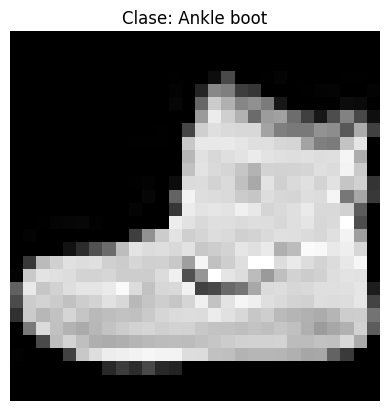

In [18]:
# Visualizar una imagen de ejemplo
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Clase: {class_names[label]}")
plt.axis(False);

---
## Punto 2 - DataLoader: ¿qué son los batches (lotes)?

**Pregunta que hice:** ¿batches es paquetes?

**Respuesta:**
Sí. Un **batch (lote)** es un paquete de muestras que se procesan juntas en cada paso del entrenamiento.

Por qué se usan:
- Procesar todo el dataset de una vez requeriría memoria enorme
- Con mini-batches, el gradiente se actualiza más seguido por época
- Mejora la eficiencia computacional

Ejemplo con `BATCH_SIZE=32`:
- 60.000 imágenes ÷ 32 = 1.875 lotes por época
- El modelo actualiza sus pesos 1.875 veces por época (no una sola)

Valores típicos de batch_size: 32, 64, 128, 256, 512 (potencias de 2)

En español se usan indistintamente: **lote** (formal) o **batch** (más común en práctica).

**Nota:** `shuffle=True` en el DataLoader de entrenamiento hace que el orden de imágenes cambie cada época, ayudando a generalizar.

In [19]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Lotes en entrenamiento: {len(train_dataloader)} × {BATCH_SIZE} imágenes")
print(f"Lotes en test:          {len(test_dataloader)} × {BATCH_SIZE} imágenes")

# Inspeccionar un lote
train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(f"Forma del lote de imágenes: {train_features_batch.shape}  →  [batch, canales, alto, ancho]")
print(f"Forma del lote de etiquetas: {train_labels_batch.shape}   →  [batch]")

Lotes en entrenamiento: 1875 × 32 imágenes
Lotes en test:          313 × 32 imágenes
Forma del lote de imágenes: torch.Size([32, 1, 28, 28])  →  [batch, canales, alto, ancho]
Forma del lote de etiquetas: torch.Size([32])   →  [batch]


**Inspección de un lote:** `next(iter(train_dataloader))` extrae el primer lote del iterador.
- `train_features_batch`: tensor de forma `[32, 1, 28, 28]`
- `train_labels_batch`: tensor de forma `[32]` (una etiqueta por imagen)

---
## Punto 3 - Model 0: Baseline

### ¿Qué hace `nn.Flatten`?

**Pregunta que hice:** ¿qué hace `nn.Flatten`?

**Respuesta:**
`nn.Flatten` convierte un tensor con varias dimensiones en un vector plano por muestra.

Por qué hace falta:
- Las capas `nn.Linear` necesitan un vector 1D de características como entrada
- Una imagen es un tensor 2D (o 3D con canales)
- `Flatten` transforma esa estructura en la lista larga que Linear necesita

```
Antes:  [1, 28, 28]  →  imagen con canales, alto, ancho
Después: [1, 784]    →  784 = 1 × 28 × 28 (todo en una fila)
```

Arquitectura del baseline (Model 0):
```
Input [1,28,28]  →  Flatten [784]  →  Linear [10]  →  Linear [10 clases]
```

In [20]:
# Demostrar qué hace Flatten
flatten_model = nn.Flatten()
x = train_features_batch[0]         # imagen individual: [1, 28, 28]
output = flatten_model(x)            # aplanar

print(f"Antes de Flatten:  {x.shape}      → [canales, alto, ancho]")
print(f"Después de Flatten: {output.shape}  → [canales, alto*ancho]")

Antes de Flatten:  torch.Size([1, 28, 28])      → [canales, alto, ancho]
Después de Flatten: torch.Size([1, 784])  → [canales, alto*ancho]


In [21]:
# Definición del Model 0 (baseline)
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

torch.manual_seed(42)
model_0 = FashionMNISTModelV0(input_shape=784, hidden_units=10, output_shape=len(class_names))
model_0.to("cpu")
print(model_0)

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)


---
## Punto 4 - Evaluación del Model 0

Idea principal: se evalúa el modelo sobre el test set y se guarda el resultado en un diccionario para comparar con modelos futuros.

La función `eval_model()` devuelve:
- `model_name`: nombre del modelo
- `model_loss`: pérdida promedio por batch
- `model_acc`: accuracy promedio por batch

Observación importante: esta primera versión de `eval_model()` no mueve tensores al dispositivo correcto. Eso genera un error más adelante (ver Punto 5 y Punto 6).

---
## Punto 5 - Código agnóstico al dispositivo

Idea principal: escribir código que funcione tanto en CPU como en GPU sin cambiarlo.

```python
device = "cuda" if torch.cuda.is_available() else "cpu"
```

Luego se pasa `device` al modelo y a los datos:
```python
model.to(device)
X, y = X.to(device), y.to(device)
```

Esto es obligatorio para que no haya mezcla de dispositivos (ver error típico en Punto 6).

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo disponible: {device}")

Dispositivo disponible: cuda


---
## Punto 6 - Model 1: No-linealidad con ReLU

**Pregunta que hice:** ¿qué es el punto 6?

**Respuesta:**
El punto 6 introduce la primera mejora sobre el baseline: añadir capas `ReLU` entre las capas lineales.

**¿Por qué ReLU?**
- Las capas `Linear` solas solo aprenden relaciones rectas (lineales)
- `ReLU` introduce curvas: devuelve 0 si la entrada es negativa, el valor si es positivo
- Esto permite capturar patrones más complejos en los datos

Comparativa arquitecturas:

| Modelo | Capas |
| --- | --- |
| Model 0 (baseline) | Flatten → Linear → Linear |
| Model 1 (ReLU)     | Flatten → Linear → **ReLU** → Linear → **ReLU** |
| Model 2 (CNN)      | Conv2d → ReLU → MaxPool2d → ... → Flatten → Linear |

**Principio de experimentación en ML:**
Cambiar solo una cosa a la vez y medir el resultado. Aquí solo se añade ReLU y se deja todo lo demás igual.

In [23]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),   # ← única diferencia respecto a Model 0
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, hidden_units=10, output_shape=10).to(device)
print(model_1)

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)


### Punto 6 (resto): entrenamiento y resultado sorprendente

**Pregunta que hice:** ¿qué pasa en el resto del punto 6?

Se resumen las subsecciones:

**6.1 Setup loss, optimizer y métricas**
- `CrossEntropyLoss` para clasificación multiclase
- `SGD` con `lr=0.1`

**6.2 Funciones reutilizables `train_step()` y `test_step()`**
- En lugar de reescribir el loop entero para cada modelo, se encapsula en funciones
- Dentro se incluye `.to(device)` para que datos y modelo estén en el mismo sitio

**Resultado:**
Model 1 (con ReLU) rinde **peor** que Model 0 (baseline). Conclusiones:
1. Más complejidad no siempre mejora
2. El modelo está haciendo **overfitting**: aprende bien el entrenamiento pero no generaliza al test

**¿Qué es overfitting?** El modelo memoriza los datos de entrenamiento en lugar de aprender patrones generales. Como estudiar solo los exámenes del año pasado sin entender el tema.

**Error técnico encontrado:** al evaluar `model_1` con la función `eval_model()` original, aparece:
```
RuntimeError: Expected all tensors to be on the same device (cuda:0 and cpu)
```
**Causa:** el modelo está en GPU pero `eval_model()` no mueve los datos.
**Solución:** añadir parámetro `device` a `eval_model()` y llamar `X.to(device)` dentro.

Entrada: [-3.0, -1.0, 0.0, 1.0, 3.0]
Despues de ReLU: [0.0, 0.0, 0.0, 1.0, 3.0]


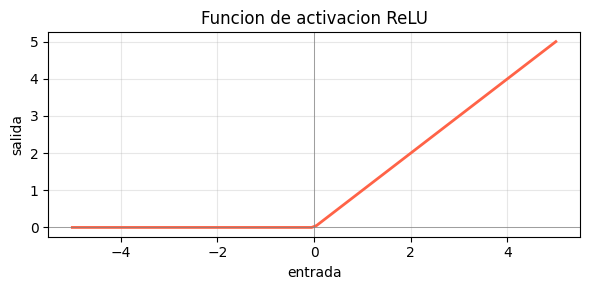

In [24]:
# Demostrar ReLU: devuelve 0 para negativos, valor para positivos
relu = nn.ReLU()
ejemplo = torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0])
print(f"Entrada: {ejemplo.tolist()}")
print(f"Despues de ReLU: {relu(ejemplo).tolist()}")

x_relu = torch.linspace(-5, 5, 100)
y_relu = relu(x_relu)
plt.figure(figsize=(6, 3))
plt.plot(x_relu.numpy(), y_relu.numpy(), color="tomato", linewidth=2)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.title("Funcion de activacion ReLU")
plt.xlabel("entrada"); plt.ylabel("salida")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## Punto 7 - Model 2: Red Neuronal Convolucional (CNN)

**Pregunta que hice:** explica de forma extensa el punto 7.

### Cambio clave respecto a los modelos anteriores
En Model 0 y Model 1, la imagen se aplana desde el primer momento → se pierde la estructura espacial.
Una **CNN** respeta y explota esa estructura 2D:
- Aplica filtros que se mueven por la imagen (convolución)
- Aprende patrones locales: bordes → texturas → formas → partes de objetos
- Por eso suele rendir mucho mejor en visión por computador

### Arquitectura TinyVGG (la que se implementa)
```
Input [1,28,28]
    ↓
Bloque 1: Conv2d → ReLU → Conv2d → ReLU → MaxPool2d
    ↓ [10, 14, 14]
Bloque 2: Conv2d → ReLU → Conv2d → ReLU → MaxPool2d
    ↓ [10, 7, 7]
Clasificador: Flatten [490] → Linear [10 clases]
    ↓
Logits de 10 clases
```

---
### ¿Qué es `Conv2d`?
Una capa convolucional que aplica filtros aprendibles sobre ventanas locales de la imagen.

Parámetros clave:
- `in_channels`: canales de entrada
- `out_channels`: número de filtros que aprende
- `kernel_size`: tamaño de la ventana (ej. 3×3)
- `stride`: salto del filtro
- `padding`: relleno en los bordes para no perder resolución

---
### ¿Qué es `MaxPool2d`?

**Pregunta que hice:** ¿qué es MaxPool2d?

**Respuesta:**
`MaxPool2d` es una capa que **reduce el tamaño espacial** de las activaciones.
No aprende pesos; solo selecciona el valor máximo de cada ventana.

Ejemplo con `kernel_size=2`:
```
Ventana 2×2:   [1, 3]   →  devuelve  3  (el mayor)
               [2, 0]
```
- Una imagen de 28×28 pasa a 14×14 después de un MaxPool2d de 2
- Reduce cómputo, reduce ruido, conserva lo más "fuerte"

---
### ¿Qué es el clasificador: Flatten + Linear final?

**Pregunta que hice:** ¿qué es el clasificador Flatten y Linear final?

**Respuesta:**
Después de los bloques convolucionales, el modelo extrajo características visuales en 3D.
Para decidir la clase hay que convertirlo en una predicción escalar:

1. **Flatten**: convierte el bloque `[10, 7, 7]` en un vector de 490 números
2. **Linear final**: toma esos 490 números y produce 10 salidas (una por clase)
3. Esas 10 salidas son **logits** → la clase con el valor más alto es la predicción

Por eso `in_features = hidden_units * 7 * 7` en el clasificador: es el resultado del tamaño espacial tras las dos capas de MaxPool2d.

In [25]:
# Demostrar MaxPool2d
max_pool = nn.MaxPool2d(kernel_size=2)
ejemplo_2d = torch.tensor([[[[1.0, 3.0], [2.0, 0.0]]]])  # [N, C, H, W]
resultado   = max_pool(ejemplo_2d)
print(f"Entrada {ejemplo_2d.shape}: {ejemplo_2d}")
print(f"Salida  {resultado.shape}: {resultado}  ← valor máximo")

Entrada torch.Size([1, 1, 2, 2]): tensor([[[[1., 3.],
          [2., 0.]]]])
Salida  torch.Size([1, 1, 1, 1]): tensor([[[[3.]]]])  ← valor máximo


In [26]:
# Arquitectura completa Model 2 (TinyVGG)
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 28×28 → 14×14
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 14×14 → 7×7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.block_2(self.block_1(x)))

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=10).to(device)
print(model_2)

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)


In [27]:
# Verificar flujo de tensores manualmente
with torch.inference_mode():
    img_test = train_features_batch[:1].to(device)  # 1 imagen: [1, 1, 28, 28]
    tras_block1 = model_2.block_1(img_test)
    tras_block2 = model_2.block_2(tras_block1)
    logits      = model_2.classifier(tras_block2)

print(f"Entrada:       {img_test.shape}")
print(f"Tras bloque 1: {tras_block1.shape}   ← MaxPool 28→14")
print(f"Tras bloque 2: {tras_block2.shape}    ← MaxPool 14→7")
print(f"Logits finales: {logits.shape}         ← 10 clases")

Entrada:       torch.Size([1, 1, 28, 28])
Tras bloque 1: torch.Size([1, 10, 14, 14])   ← MaxPool 28→14
Tras bloque 2: torch.Size([1, 10, 7, 7])    ← MaxPool 14→7
Logits finales: torch.Size([1, 10])         ← 10 clases


In [28]:
# ────────────────────────────────────────────────────────
# ENTRENAMIENTO COMPLETO DE LOS 3 MODELOS
# ────────────────────────────────────────────────────────
from timeit import default_timer as timer
import requests, sys
from pathlib import Path as _Path

if not _Path("../helper_functions.py").is_file():
    r = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    open("../helper_functions.py", "wb").write(r.content)
sys.path.insert(0, "..")
from helper_functions import accuracy_fn

EPOCHS = 3

# Reiniciar modelos con pesos nuevos para comparacion limpia
torch.manual_seed(42)
model_0 = FashionMNISTModelV0(input_shape=784, hidden_units=10, output_shape=len(class_names)).to("cpu")
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, hidden_units=10, output_shape=len(class_names)).to(device)
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,   hidden_units=10, output_shape=len(class_names)).to(device)

def _train_step(model, loader, loss_fn, optimizer, dev):
    total_loss, total_acc = 0, 0
    model.to(dev).train()
    for X, y in loader:
        X, y = X.to(dev), y.to(dev)
        pred = model(X); loss = loss_fn(pred, y)
        total_loss += loss.item()
        total_acc  += accuracy_fn(y_true=y, y_pred=pred.argmax(dim=1))
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    return total_loss / len(loader), total_acc / len(loader)

def _test_step(model, loader, loss_fn, dev):
    total_loss, total_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in loader:
            X, y = X.to(dev), y.to(dev)
            pred = model(X)
            total_loss += loss_fn(pred, y).item()
            total_acc  += accuracy_fn(y_true=y, y_pred=pred.argmax(dim=1))
    return total_loss / len(loader), total_acc / len(loader)

history = {}
for nombre, modelo, dev in [
    ("Model 0 (baseline)", model_0, "cpu"),
    ("Model 1 (ReLU)",     model_1, device),
    ("Model 2 (CNN)",      model_2, device),
]:
    torch.manual_seed(42)
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(modelo.parameters(), lr=0.1)
    hist = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    t0 = timer()
    print(f"\nEntrenando {nombre}...")
    for epoch in range(EPOCHS):
        tr_l, tr_a = _train_step(modelo, train_dataloader, loss_fn, optimizer, dev)
        te_l, te_a = _test_step(modelo,  test_dataloader,  loss_fn, dev)
        hist["train_loss"].append(tr_l); hist["train_acc"].append(tr_a)
        hist["test_loss"].append(te_l);  hist["test_acc"].append(te_a)
        print(f"  Epoca {epoch+1}/{EPOCHS}  train_loss={tr_l:.4f}  test_loss={te_l:.4f}  test_acc={te_a:.2f}%")
    hist["tiempo"] = timer() - t0
    history[nombre] = hist
    print(f"  Tiempo: {hist['tiempo']:.1f}s")

print("\n[OK] Entrenamiento completado.")


Entrenando Model 0 (baseline)...
  Epoca 1/3  train_loss=0.5904  test_loss=0.5095  test_acc=82.04%
  Epoca 2/3  train_loss=0.4763  test_loss=0.4799  test_acc=83.20%
  Epoca 3/3  train_loss=0.4550  test_loss=0.4766  test_acc=83.43%
  Tiempo: 51.1s

Entrenando Model 1 (ReLU)...
  Epoca 1/3  train_loss=1.0920  test_loss=0.9564  test_acc=65.00%
  Epoca 2/3  train_loss=0.7810  test_loss=0.7223  test_acc=73.91%
  Epoca 3/3  train_loss=0.6703  test_loss=0.6850  test_acc=75.02%
  Tiempo: 55.7s

Entrenando Model 2 (CNN)...
  Epoca 1/3  train_loss=0.5887  test_loss=0.3922  test_acc=85.77%
  Epoca 2/3  train_loss=0.3619  test_loss=0.3454  test_acc=87.12%
  Epoca 3/3  train_loss=0.3257  test_loss=0.3279  test_acc=87.91%
  Tiempo: 75.6s

[OK] Entrenamiento completado.


---
## Punto 8 - Comparar modelos (con resultados reales)

Idea principal: después de entrenar los 3 modelos, se comparan en accuracy, loss y tiempo.

**Trade-off rendimiento vs velocidad:**
- Mejor rendimiento suele costar más tiempo de entrenamiento
- Para datasets pequeños, la CPU puede ser más rápida que la GPU

**Conclusión:** la CNN supera a ambos modelos lineales porque respeta la estructura espacial de las imágenes.

In [29]:
import pandas as pd

resultados = []
for nombre, hist in history.items():
    resultados.append({
        "Modelo":       nombre,
        "Test loss":    round(hist["test_loss"][-1], 4),
        "Test acc (%)": round(hist["test_acc"][-1],  2),
        "Tiempo (s)":   round(hist["tiempo"],         1),
    })
df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False))

            Modelo  Test loss  Test acc (%)  Tiempo (s)
Model 0 (baseline)     0.4766         83.43        51.1
    Model 1 (ReLU)     0.6850         75.02        55.7
     Model 2 (CNN)     0.3279         87.91        75.6


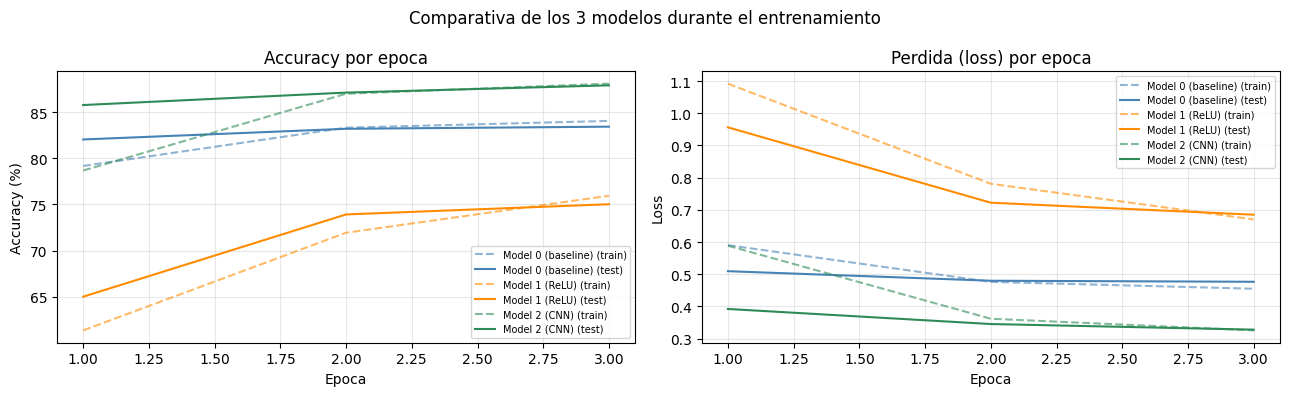

In [30]:
colores = ["steelblue", "darkorange", "seagreen"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for (nombre, hist), color in zip(history.items(), colores):
    epocas = range(1, EPOCHS + 1)
    axes[0].plot(epocas, hist["train_acc"],  linestyle="--", color=color, alpha=0.6, label=f"{nombre} (train)")
    axes[0].plot(epocas, hist["test_acc"],   linestyle="-",  color=color,            label=f"{nombre} (test)")
    axes[1].plot(epocas, hist["train_loss"], linestyle="--", color=color, alpha=0.6, label=f"{nombre} (train)")
    axes[1].plot(epocas, hist["test_loss"],  linestyle="-",  color=color,            label=f"{nombre} (test)")

axes[0].set_title("Accuracy por epoca"); axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)
axes[1].set_title("Perdida (loss) por epoca"); axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

plt.suptitle("Comparativa de los 3 modelos durante el entrenamiento", fontsize=12)
plt.tight_layout(); plt.show()

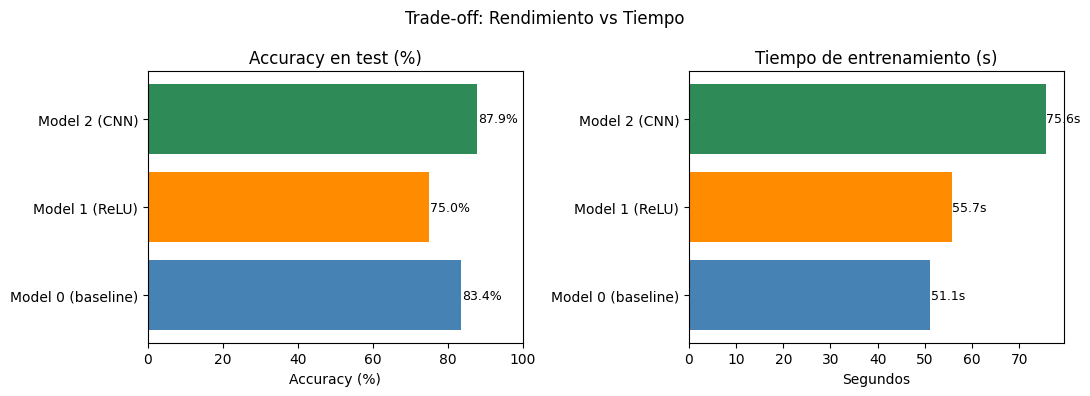

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

nombres   = df_res["Modelo"].tolist()
acc_vals  = df_res["Test acc (%)"].tolist()
time_vals = df_res["Tiempo (s)"].tolist()

axes[0].barh(nombres, acc_vals,  color=colores)
axes[0].set_title("Accuracy en test (%)"); axes[0].set_xlabel("Accuracy (%)"); axes[0].set_xlim(0, 100)
for i, v in enumerate(acc_vals):  axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

axes[1].barh(nombres, time_vals, color=colores)
axes[1].set_title("Tiempo de entrenamiento (s)"); axes[1].set_xlabel("Segundos")
for i, v in enumerate(time_vals): axes[1].text(v + 0.1, i, f"{v:.1f}s", va="center", fontsize=9)

plt.suptitle("Trade-off: Rendimiento vs Tiempo", fontsize=12)
plt.tight_layout(); plt.show()

---
## Punto 9 - Evaluar el mejor modelo con predicciones visuales

Idea principal: tomar imágenes aleatorias del test set, hacer predicciones con `model_2` y visualizarlas.

Flujo de predicción:
```
imagen → unsqueeze (añadir dim de batch) → model → logits → softmax → argmax → clase predicha
```

La visualización colorea el título en:
- **Verde** si la predicción es correcta
- **Rojo** si es incorrecta

Esto ayuda a ver visualmente dónde y cómo se equivoca el modelo.

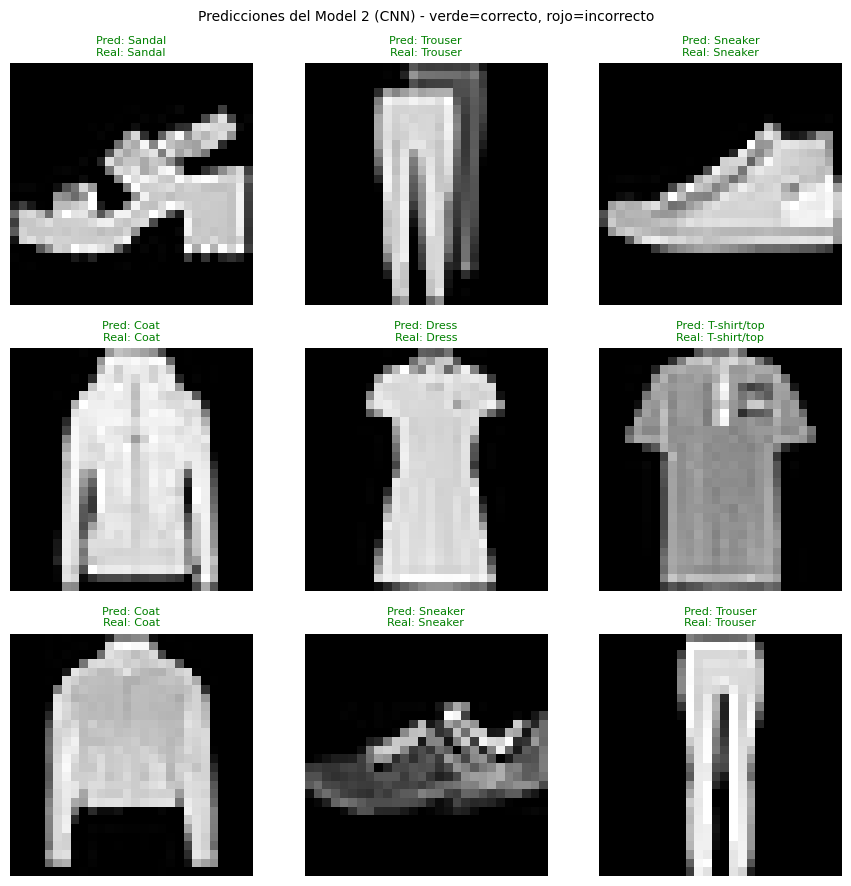

In [32]:
# ── Punto 9: predicciones visuales con model_2 (el mejor) ──
import random
random.seed(42)
test_samples, test_labels_list = [], []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels_list.append(label)

model_2.eval()
pred_probs_list = []
with torch.inference_mode():
    for sample in test_samples:
        s = sample.unsqueeze(0).to(device)
        logit = model_2(s)
        prob  = torch.softmax(logit.squeeze(), dim=0)
        pred_probs_list.append(prob.cpu())

pred_probs_tensor = torch.stack(pred_probs_list)
pred_classes = pred_probs_tensor.argmax(dim=1)

fig = plt.figure(figsize=(9, 9))
for i, (sample, true_lbl, pred_lbl) in enumerate(zip(test_samples, test_labels_list, pred_classes)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample.squeeze(), cmap="gray")
    pred_name  = class_names[pred_lbl]
    true_name  = class_names[true_lbl]
    color      = "green" if pred_name == true_name else "red"
    plt.title(f"Pred: {pred_name}\nReal: {true_name}", fontsize=8, c=color)
    plt.axis(False)

plt.suptitle("Predicciones del Model 2 (CNN) - verde=correcto, rojo=incorrecto", fontsize=10)
plt.tight_layout()
plt.show()

---
## Punto 10 - Matriz de confusión

**Pregunta que hice:** explica los puntos 10 y 11.

**Respuesta sobre el 10:**

La **matriz de confusión** va más allá del accuracy: muestra exactamente en qué clases se equivoca el modelo.

Cómo leerla:
- **Filas**: clase real
- **Columnas**: clase predicha
- **Diagonal**: aciertos (idealmente todos los valores aquí)
- **Fuera de diagonal**: confusiones (errores)

Para qué sirve:
1. Ver si hay clases sistemáticamente confundidas (ej. Shirt ↔ T-shirt/top)
2. Decidir si es un problema del modelo o del dataset (clases muy parecidas)
3. Guiar mejoras concretas: más datos de ciertas clases, data augmentation, mejor arquitectura

Herramientas usadas:
- `torchmetrics.ConfusionMatrix` para calcularla
- `mlxtend.plotting.plot_confusion_matrix` para visualizarla

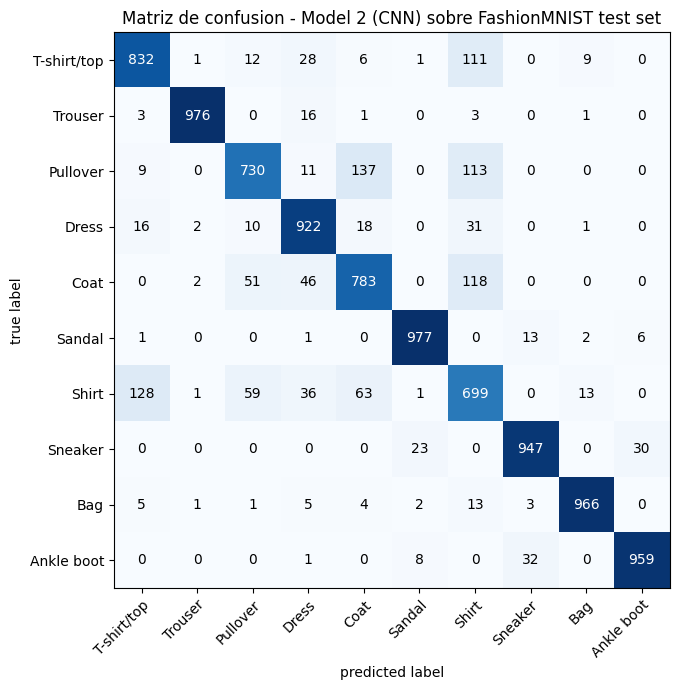

Clases mas confundidas: ver celdas fuera de la diagonal principal.


In [33]:
# ── Punto 10: Matriz de confusion real con model_2 ──
try:
    import torchmetrics, mlxtend
    assert int(mlxtend.__version__.split(".")[1]) >= 19
except:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torchmetrics", "-U", "mlxtend"], check=True)
    import torchmetrics, mlxtend

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Generar predicciones sobre TODO el test set
y_preds = []
model_2.eval()
with torch.inference_mode():
    for X, y in test_dataloader:
        X = X.to(device)
        y_logit = model_2(X)
        y_pred  = torch.softmax(y_logit, dim=1).argmax(dim=1)
        y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)

confmat        = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)
plt.title("Matriz de confusion - Model 2 (CNN) sobre FashionMNIST test set")
plt.tight_layout()
plt.show()

print("Clases mas confundidas: ver celdas fuera de la diagonal principal.")

---
## Punto 11 - Guardar y cargar el mejor modelo

**Respuesta sobre el 11:**

Una vez entrenado, queremos conservar el modelo para usarlo luego sin reentrenar.

Proceso:
1. **Guardar** los pesos aprendidos (`state_dict`) en un archivo `.pth`
2. **Crear** una nueva instancia del modelo con la misma arquitectura
3. **Cargar** los pesos en esa instancia
4. **Verificar** que el modelo cargado rinde igual que el original

Por qué guardar `state_dict` y no el modelo entero:
- El `state_dict` solo guarda los pesos, no la arquitectura
- Es más portable y resistente a cambios en el código
- Para cargarlo solo necesitas que la arquitectura sea compatible

Error típico al cargar: si los `hidden_units` o formas no coinciden entre el modelo guardado y el nuevo, falla.

In [34]:
from pathlib import Path

# --- Guardar ---
MODEL_PATH = Path("../models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / "03_apuntes_model_2.pth"

# Guardamos los pesos aprendidos (state_dict)
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)
print(f"Modelo guardado en: {MODEL_SAVE_PATH}")

# --- Cargar ---
# Se necesita crear la misma arquitectura antes de cargar pesos
loaded_model = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=10)
loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH, map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()
print("Modelo cargado correctamente.")

Modelo guardado en: ..\models\03_apuntes_model_2.pth
Modelo cargado correctamente.


In [35]:
# Verificar que el modelo cargado produce las mismas salidas
with torch.inference_mode():
    logits_original = model_2(img_test)
    logits_cargado  = loaded_model(img_test)

iguales = torch.allclose(logits_original, logits_cargado, atol=1e-6)
print(f"¿Logits originales == logits cargados? {iguales}")

¿Logits originales == logits cargados? True


---
## Resumen final: Lo aprendido en el capítulo 03

### Conceptos clave consolidados

**Datos:**
- FashionMNIST = dataset de ropa de 10 clases, imágenes 28×28 en escala de grises
- `Dataset` + `DataLoader` dividen los datos en **batches (lotes)** para entrenar en partes
- `shuffle=True` en entrenamiento ayuda a generalizar

**Arquitecturas:**
- `nn.Flatten` convierte la imagen 2D en vector para capas lineales
- `nn.ReLU` añade no-linealidad, pero más complejidad no siempre mejora
- `nn.Conv2d` extrae patrones visuales locales respetando la estructura espacial
- `nn.MaxPool2d` reduce tamaño conservando lo más relevante
- El **clasificador** (Flatten + Linear) convierte características visuales en logits de clase

**Evaluación:**
- **Accuracy** dice cuánto acierta, pero la **matriz de confusión** dice dónde falla
- Útil para detectar confusiones sistemáticas entre clases similares

**Problemas encontrados y soluciones:**
1. **Overfitting** (Model 1 ← ReLU empeora): el modelo memoriza en vez de generalizar
   - Solución: cambiar arquitectura (CNN) o usar más datos
2. **Error de device** (`cuda:0` vs `cpu`): mezcla de dispositivos en evaluación
   - Solución: pasar `device` a `eval_model()` y mover `X.to(device)` dentro

**Lección de ML del capítulo:**
> No siempre lo que "debería funcionar" funciona. La elección de arquitectura adecuada al tipo de datos (CNN para imágenes) suele tener más impacto que ajustes menores. La experimentación sistemática — cambiar una cosa a la vez — es la forma correcta de mejorar.